# Training strategy comparison

Comparison of baseline, adaptive weighting, adaptive weighting with MLP heads, Group DRO, and separate-task training for RoBERTa full fine-tuning and Qwen LoRA. Qwen3-Embedding-8B baseline, adaptive, and Group DRO now contain five splits.

RoBERTa and Qwen 0.6B comparisons use seeds 2026–2028. Qwen 8B is reported only over its completed seeds 2026–2030; the earlier three-split aggregates are omitted.

$$score = \frac{\min(F1_{sent,AU},F1_{sent,UK}) + \min(F1_{sarc,AU},F1_{sarc,UK})}{2}.$$

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titleweight": "bold"})

def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "training_summary" / "runs").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate training_summary/runs")

RUN_ROOT = find_repo_root() / "training_summary" / "runs"
COMMON_SEEDS = (2026, 2027, 2028)
EXTENDED_SEEDS = (2026, 2027, 2028, 2029, 2030)

RUNS = {
    "RoBERTa · Baseline": ("R1", "roberta_multitask", "RoBERTa", "Baseline"),
    "RoBERTa · Adaptive": ("R2", "roberta_adaptive_minvariety", "RoBERTa", "Adaptive"),
    "RoBERTa · Adaptive MLP": ("R3", "roberta_adaptive_minvariety_mlp", "RoBERTa", "Adaptive MLP"),
    "RoBERTa · Group DRO": ("R4", "roberta_group_dro", "RoBERTa", "Group DRO"),
    "RoBERTa · Separate tasks": ("R5", "roberta_separate_tasks", "RoBERTa", "Separate tasks"),
    "Qwen · Baseline": ("Q1", "qwen_embedding_0.6b_multitask_lora", "Qwen", "Baseline"),
    "Qwen · Adaptive": ("Q2", "qwen_embedding_0.6b_lora_adaptive_minvariety", "Qwen", "Adaptive"),
    "Qwen · Adaptive MLP": ("Q3", "qwen_embedding_0.6b_lora_adaptive_minvariety_mlp", "Qwen", "Adaptive MLP"),
    "Qwen · Group DRO": ("Q4", "qwen_embedding_0.6b_lora_group_dro", "Qwen", "Group DRO"),
    "Qwen · Separate tasks": ("Q5", "qwen_embedding_0.6b_lora_separate_tasks", "Qwen", "Separate tasks"),
    "Qwen 8B · Baseline": ("Q8-1", "qwen_embedding_8b_multitask_lora", "Qwen 8B", "Baseline"),
    "Qwen 8B · Adaptive": ("Q8-2", "qwen_embedding_8b_lora_adaptive_minvariety", "Qwen 8B", "Adaptive"),
    "Qwen 8B · Group DRO": ("Q8-3", "qwen_embedding_8b_lora_group_dro", "Qwen 8B", "Group DRO"),
}
STRATEGIES = ("Baseline", "Adaptive", "Adaptive MLP", "Group DRO", "Separate tasks")
MODELS = ("RoBERTa", "Qwen")
COLORS = {"Baseline": "#4C78A8", "Adaptive": "#E45756",
          "Adaptive MLP": "#72B7B2", "Group DRO": "#F2CF5B",
          "Separate tasks": "#B279A2"}

SUBTASKS = {
    "Sentiment AU": "en_AU_sentiment_macro_f1",
    "Sentiment UK": "en_UK_sentiment_macro_f1",
    "Sarcasm AU": "en_AU_sarcasm_macro_f1",
    "Sarcasm UK": "en_UK_sarcasm_macro_f1",
}

def benchmark_score(frame):
    # Written by the organiser-provided scorer during evaluation.
    return frame["selection_score"]

frames = []
for run, (run_id, directory, model, strategy) in RUNS.items():
    path = RUN_ROOT / directory / "all_results.csv"
    if not path.is_file():
        raise FileNotFoundError(path)
    frame = pd.read_csv(path)
    frame.columns = [column.removeprefix("test_") for column in frame.columns]
    frame["split_seed"] = frame.split_seed.astype(int)
    frame["run"], frame["id"] = run, run_id
    frame["model"], frame["strategy"] = model, strategy
    frame["benchmark_score"] = benchmark_score(frame)
    frames.append(frame)

results = pd.concat(frames, ignore_index=True)
common = results[(results.model != "Qwen 8B")
                 & results.split_seed.isin(COMMON_SEEDS)].copy()
coverage = results.groupby(["id", "run"], sort=False).split_seed.agg(["count", "min", "max"])
display(coverage.rename(columns={"count": "n_seeds", "min": "first_seed", "max": "last_seed"}))

,,n_seeds,first_seed,last_seed
id,run,,,
R1,RoBERTa · Baseline,3,2026,2028
R2,RoBERTa · Adaptive,3,2026,2028
R3,RoBERTa · Adaptive MLP,3,2026,2028
R4,RoBERTa · Group DRO,5,2026,2030
R5,RoBERTa · Separate tasks,5,2026,2030
Q1,Qwen · Baseline,3,2026,2028
Q2,Qwen · Adaptive,3,2026,2028
Q3,Qwen · Adaptive MLP,3,2026,2028
Q4,Qwen · Group DRO,5,2026,2030


### Comparability

- Main comparisons use the same three splits.
- All runs use five epochs, maximum length 256, dropout 0.1, weight decay 0.01, and warmup ratio 0.1.
- RoBERTa and Qwen 0.6B use effective batch size 16; Qwen 8B uses batch size 8 without accumulation. Size comparisons are therefore not a pure scaling ablation.
- RoBERTa is fully fine-tuned at 2e-5; Qwen uses LoRA at 2e-4.
- Strategies intentionally differ in objective, head, checkpoint selection, or backbone sharing.
- Test data is evaluated only after validation-based checkpoint selection.

## Common-seed summary and benchmark score

,Backbone,Strategy,Sentiment AU,Sentiment UK,Sarcasm AU,Sarcasm UK,Score
ID,,,,,,,
R1,RoBERTa,Baseline,0.9132 ± 0.0094,0.9497 ± 0.0067,0.7670 ± 0.0195,0.6445 ± 0.0100,0.7789 ± 0.0090
R2,RoBERTa,Adaptive,0.9152 ± 0.0103,0.9445 ± 0.0030,0.7362 ± 0.0238,0.6508 ± 0.0149,0.7830 ± 0.0032
R3,RoBERTa,Adaptive MLP,0.9090 ± 0.0016,0.9410 ± 0.0055,0.7647 ± 0.0249,0.6809 ± 0.0175,0.7949 ± 0.0095
R4,RoBERTa,Group DRO,0.9135 ± 0.0072,0.9480 ± 0.0026,0.7468 ± 0.0180,0.6721 ± 0.0191,0.7928 ± 0.0114
R5,RoBERTa,Separate tasks,0.9133 ± 0.0025,0.9488 ± 0.0076,0.7344 ± 0.0085,0.6892 ± 0.0146,0.8012 ± 0.0079
Q1,Qwen,Baseline,0.9206 ± 0.0069,0.9497 ± 0.0040,0.7774 ± 0.0129,0.6699 ± 0.0441,0.7953 ± 0.0255
Q2,Qwen,Adaptive,0.9195 ± 0.0031,0.9567 ± 0.0104,0.7543 ± 0.0138,0.6874 ± 0.0386,0.8034 ± 0.0189
Q3,Qwen,Adaptive MLP,0.9133 ± 0.0025,0.9575 ± 0.0061,0.7339 ± 0.0341,0.6930 ± 0.0302,0.8031 ± 0.0159
Q4,Qwen,Group DRO,0.9231 ± 0.0032,0.9489 ± 0.0040,0.7426 ± 0.0241,0.7016 ± 0.0165,0.8123 ± 0.0094


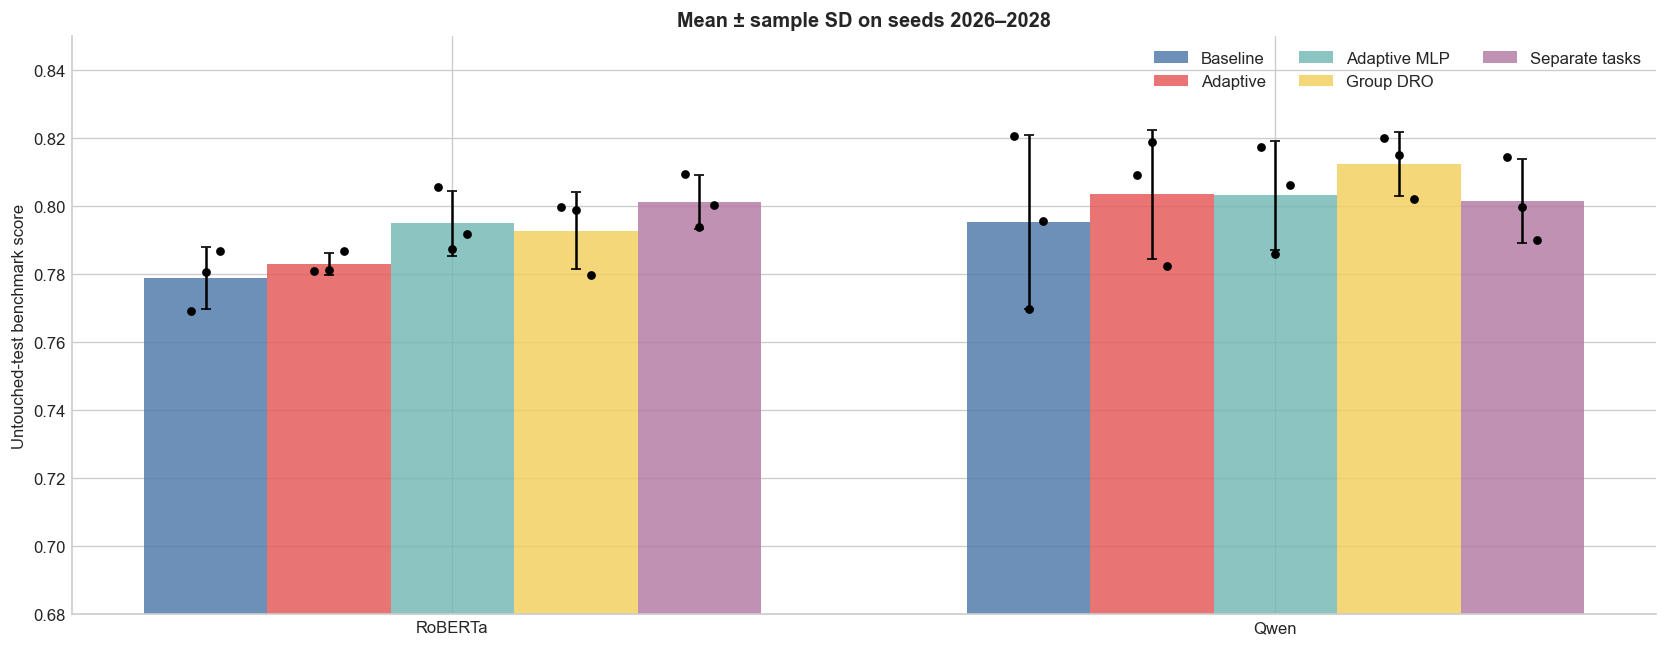

In [2]:
rows = []
for run, part in common.groupby("run", sort=False):
    run_id, _, model, strategy = RUNS[run]
    row = {"ID": run_id, "Backbone": model, "Strategy": strategy}
    for label, metric in SUBTASKS.items():
        row[label] = f"{part[metric].mean():.4f} ± {part[metric].std():.4f}"
    row["Score"] = f"{part.benchmark_score.mean():.4f} ± {part.benchmark_score.std():.4f}"
    rows.append(row)
display(pd.DataFrame(rows).set_index("ID"))

fig, ax = plt.subplots(figsize=(14, 5.5))
x, width = np.arange(len(MODELS)), 0.15
for offset, strategy in zip(np.linspace(-2 * width, 2 * width, len(STRATEGIES)), STRATEGIES):
    means, stds = [], []
    for model in MODELS:
        values = common[(common.model == model) & (common.strategy == strategy)].benchmark_score
        means.append(values.mean() if len(values) else np.nan)
        stds.append(values.std() if len(values) else np.nan)
    positions = x + offset
    ax.bar(positions, means, width, yerr=stds, capsize=3,
           color=COLORS[strategy], alpha=0.82, label=strategy)
    for index, model in enumerate(MODELS):
        values = common[(common.model == model) & (common.strategy == strategy)].benchmark_score.to_numpy()
        if len(values):
            ax.scatter(np.full(len(values), positions[index]) + np.linspace(-0.018, 0.018, len(values)),
                       values, color="black", s=18, zorder=3)
ax.set_xticks(x, MODELS); ax.set_ylim(0.68, 0.85)
ax.set_ylabel("Untouched-test benchmark score")
ax.set_title("Mean ± sample SD on seeds 2026–2028")
ax.legend(frameon=False, ncol=3)
fig.tight_layout(); plt.show()

## Four score components

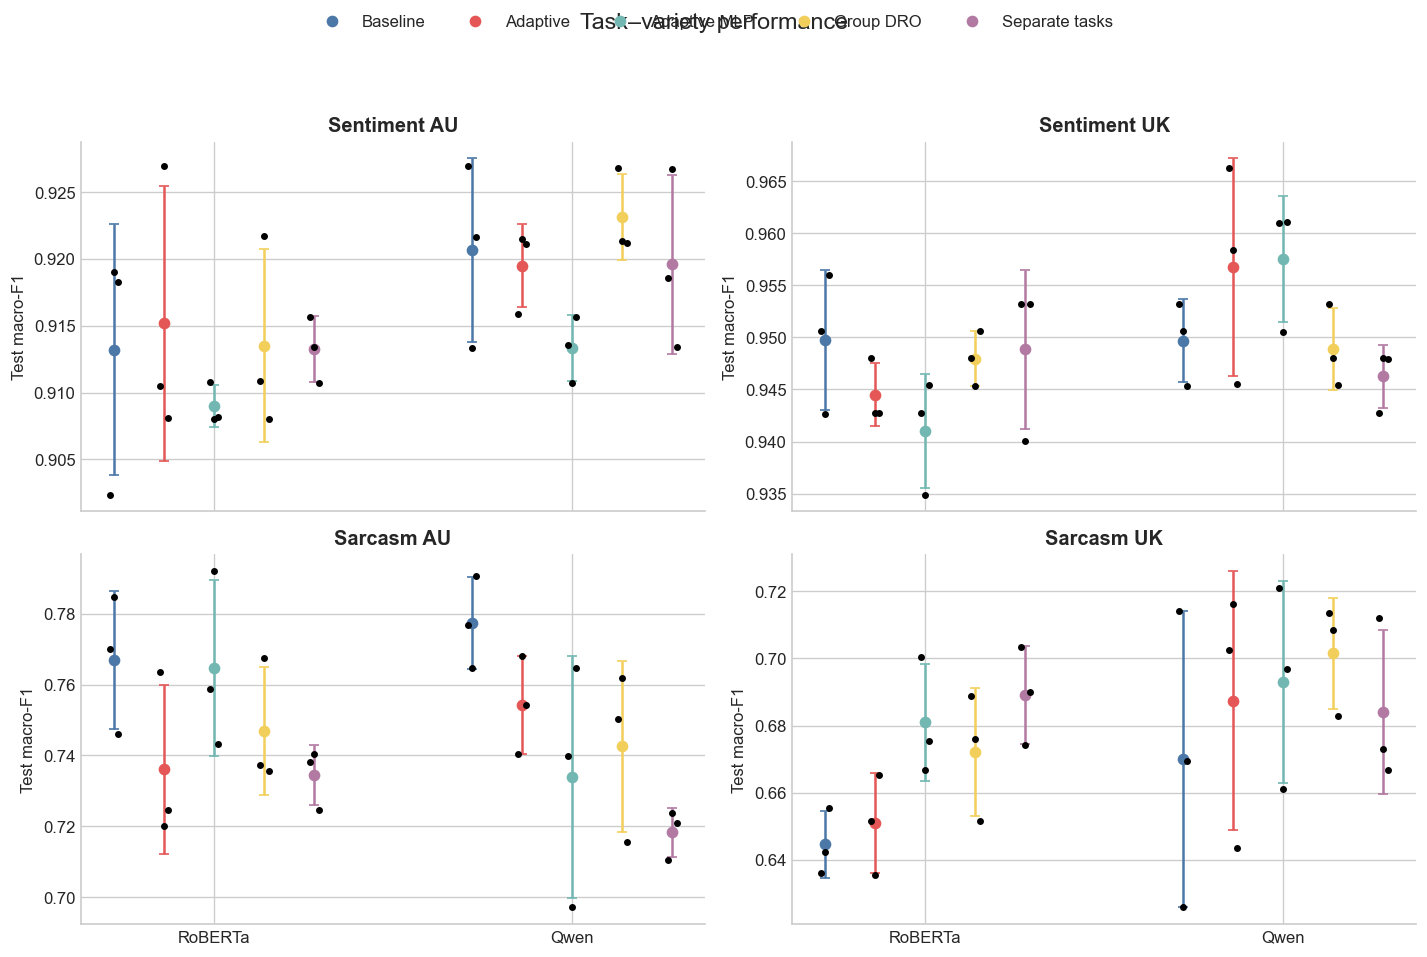

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
x = np.arange(len(MODELS))
for ax, (label, metric) in zip(axes.flat, SUBTASKS.items()):
    for offset, strategy in zip(np.linspace(-0.28, 0.28, len(STRATEGIES)), STRATEGIES):
        for index, model in enumerate(MODELS):
            values = common[(common.model == model) & (common.strategy == strategy)][metric]
            if len(values):
                position = x[index] + offset
                ax.errorbar(position, values.mean(), yerr=values.std(), fmt="o", capsize=3,
                            color=COLORS[strategy], markersize=6)
                ax.scatter(np.full(len(values), position) + np.linspace(-0.012, 0.012, len(values)),
                           values, color="black", s=10, zorder=3)
    ax.set_title(label); ax.set_xticks(x, MODELS); ax.set_ylabel("Test macro-F1")
handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=COLORS[s], label=s)
           for s in STRATEGIES]
fig.legend(handles=handles, loc="upper center", ncol=5, frameon=False)
fig.suptitle("Task–variety performance", y=0.99, fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.94)); plt.show()

## Paired change from baseline

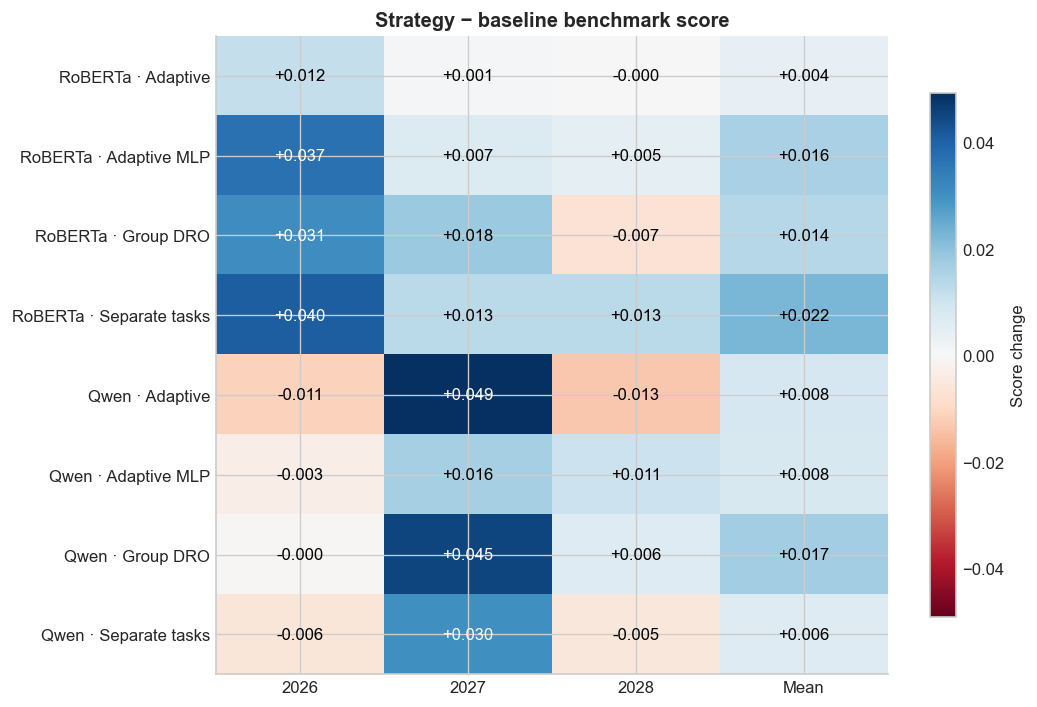

In [4]:
delta_rows = []
for model in MODELS:
    baseline = common[(common.model == model) & (common.strategy == "Baseline")].set_index("split_seed")
    available = common[common.model == model].strategy.unique()
    for strategy in [name for name in STRATEGIES[1:] if name in available]:
        candidate = common[(common.model == model) & (common.strategy == strategy)].set_index("split_seed")
        delta = candidate.benchmark_score - baseline.benchmark_score
        delta_rows.append({"comparison": f"{model} · {strategy}",
                           **{str(seed): delta.loc[seed] for seed in COMMON_SEEDS},
                           "Mean": delta.mean()})
deltas = pd.DataFrame(delta_rows).set_index("comparison")
fig, ax = plt.subplots(figsize=(9, 6))
limit = np.abs(deltas.to_numpy()).max()
image = ax.imshow(deltas, cmap="RdBu", vmin=-limit, vmax=limit, aspect="auto")
ax.set_xticks(range(len(deltas.columns)), deltas.columns)
ax.set_yticks(range(len(deltas.index)), deltas.index)
ax.set_title("Strategy − baseline benchmark score")
for row in range(deltas.shape[0]):
    for column in range(deltas.shape[1]):
        value = deltas.iloc[row, column]
        ax.text(column, row, f"{value:+.3f}", ha="center", va="center",
                color="white" if abs(value) > limit * 0.55 else "black")
fig.colorbar(image, ax=ax, label="Score change", shrink=0.82)
fig.tight_layout(); plt.show()

## Five-seed stability of completed 0.6B and RoBERTa strategies

This is supplementary because the other 0.6B and RoBERTa strategies do not yet contain seeds 2029–2030. Qwen 8B is analysed separately below.

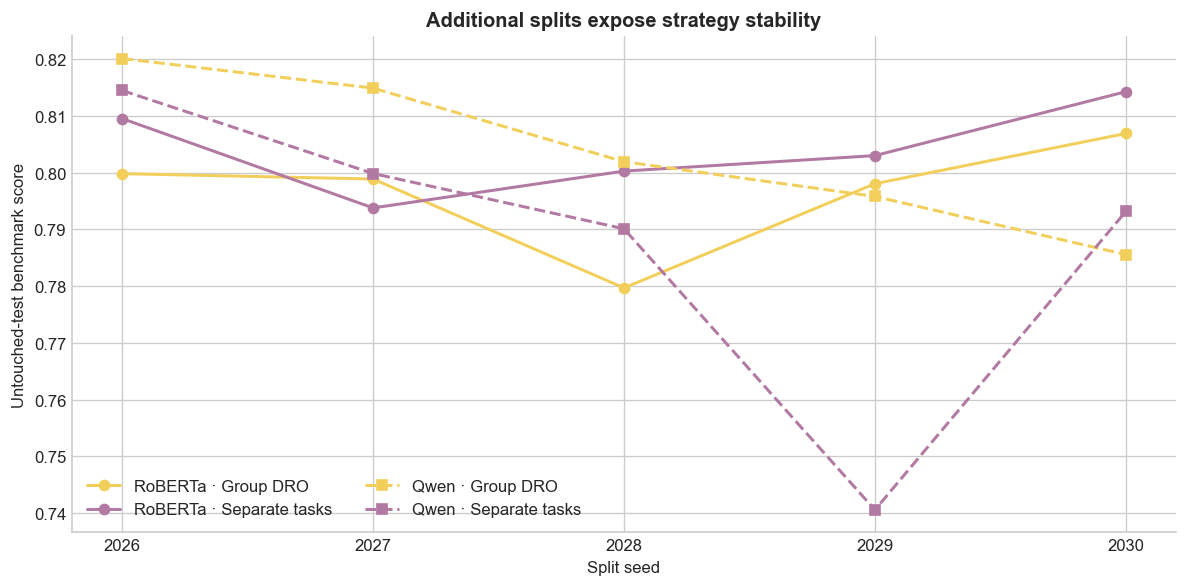

,,mean,std,min,max
model,strategy,,,,
RoBERTa,Separate tasks,0.8042,0.0080,0.7938,0.8143
Qwen,Group DRO,0.8037,0.0141,0.7856,0.8201
RoBERTa,Group DRO,0.7967,0.0101,0.7797,0.8069
Qwen,Separate tasks,0.7876,0.0280,0.7405,0.8145


In [5]:
run_seed_counts = results.groupby("run").split_seed.nunique()
five_seed_runs = run_seed_counts[run_seed_counts >= 5].index
extended = results[results.run.isin(five_seed_runs)
                   & (results.model != "Qwen 8B")
                   & results.strategy.isin(["Group DRO", "Separate tasks"])
                   & results.split_seed.isin(EXTENDED_SEEDS)].copy()
fig, ax = plt.subplots(figsize=(10, 5))
for run, part in extended.groupby("run", sort=False):
    part = part.sort_values("split_seed")
    model, strategy = part.model.iloc[0], part.strategy.iloc[0]
    ax.plot(part.split_seed.astype(str), part.benchmark_score,
            marker="o" if model == "RoBERTa" else "s",
            linestyle="-" if model == "RoBERTa" else "--",
            color=COLORS[strategy], linewidth=1.8, label=run)
ax.set_xlabel("Split seed"); ax.set_ylabel("Untouched-test benchmark score")
ax.set_title("Additional splits expose strategy stability")
ax.legend(frameon=False, ncol=2); fig.tight_layout(); plt.show()

extended_summary = (extended.groupby(["model", "strategy"], sort=False).benchmark_score
                    .agg(["mean", "std", "min", "max"]).sort_values("mean", ascending=False))
display(extended_summary.style.format("{:.4f}"))

## Qwen 8B five-split results

All three 8B strategies use seeds 2026–2030. Error bars are sample standard deviations across splits.

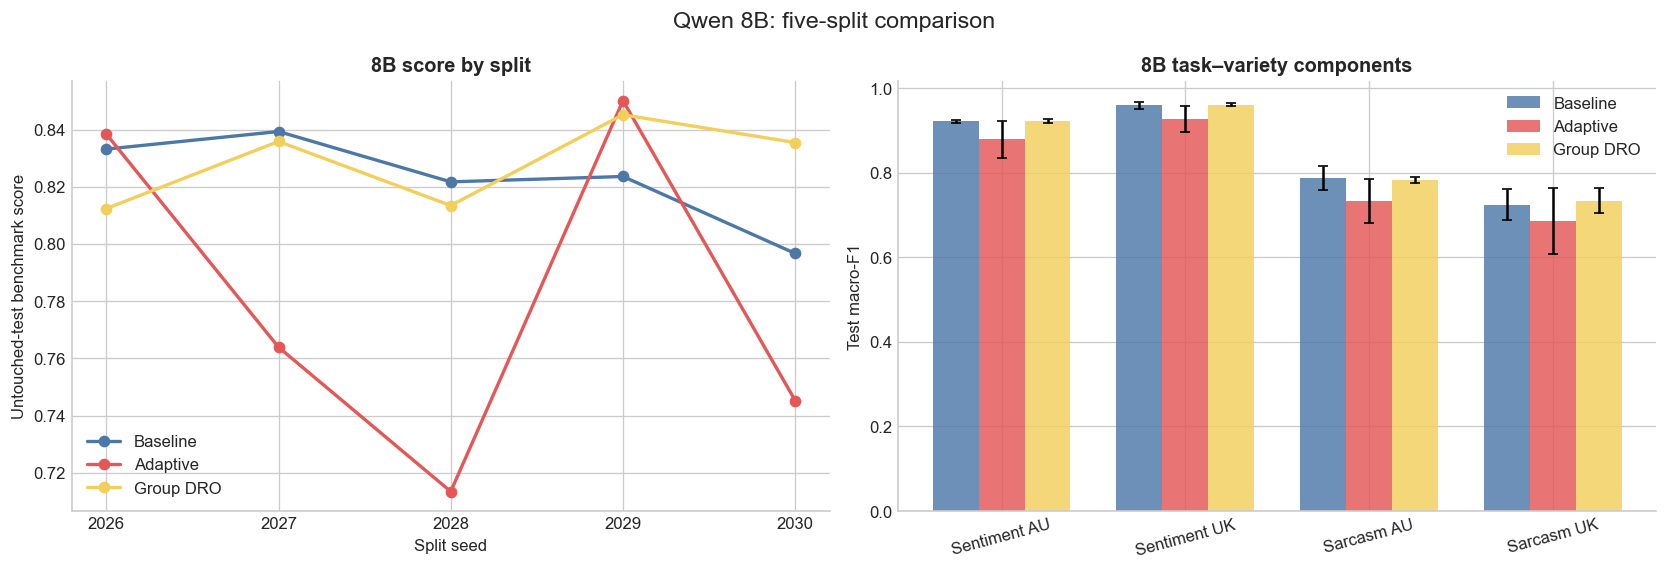

In [6]:
qwen8_strategies = ("Baseline", "Adaptive", "Group DRO")
qwen8_five = results[(results.model == "Qwen 8B")
                     & results.split_seed.isin(EXTENDED_SEEDS)].copy()
qwen8_metrics = [*SUBTASKS.values(), "benchmark_score"]
qwen8_summary = qwen8_five.groupby("strategy")[qwen8_metrics].agg(["mean", "std"])
display(qwen8_summary.style.format("{:.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for strategy in qwen8_strategies:
    part = qwen8_five[qwen8_five.strategy == strategy].sort_values("split_seed")
    axes[0].plot(part.split_seed.astype(str), part.benchmark_score, marker="o",
                 linewidth=2, color=COLORS[strategy], label=strategy)
axes[0].set_xlabel("Split seed"); axes[0].set_ylabel("Untouched-test benchmark score")
axes[0].set_title("8B score by split"); axes[0].legend(frameon=False)

x, width = np.arange(len(SUBTASKS)), 0.25
for offset, strategy in zip((-width, 0, width), qwen8_strategies):
    part = qwen8_five[qwen8_five.strategy == strategy]
    means = [part[metric].mean() for metric in SUBTASKS.values()]
    stds = [part[metric].std() for metric in SUBTASKS.values()]
    axes[1].bar(x + offset, means, width, yerr=stds, capsize=3, alpha=0.82,
                color=COLORS[strategy], label=strategy)
axes[1].set_xticks(x, SUBTASKS.keys(), rotation=15); axes[1].set_ylabel("Test macro-F1")
axes[1].set_title("8B task–variety components"); axes[1].legend(frameon=False)
fig.suptitle("Qwen 8B: five-split comparison", fontsize=14)
fig.tight_layout(); plt.show()

### Qwen 8B validation trajectories

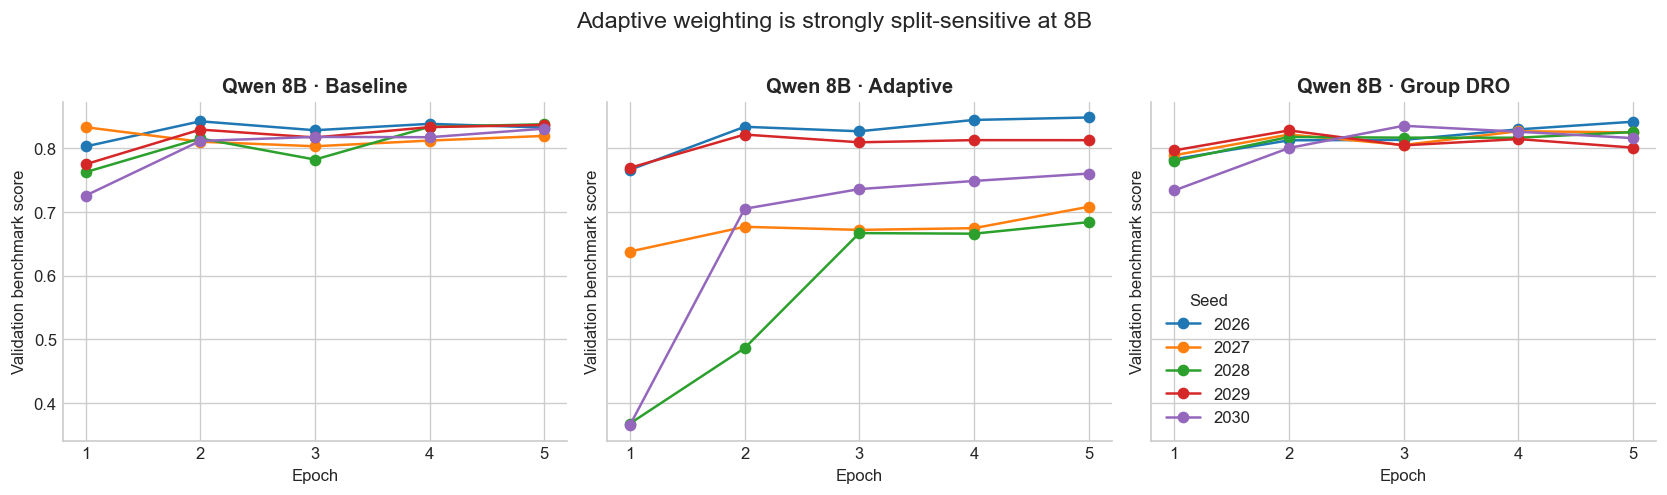

In [7]:
qwen8_runs = [run for run in RUNS if run.startswith("Qwen 8B")]
history_rows = []
for run in qwen8_runs:
    _, directory, _, strategy = RUNS[run]
    for seed in EXTENDED_SEEDS:
        epoch_history = json.loads(
            (RUN_ROOT / directory / f"seed_{seed}" / "history.json").read_text()
        )
        for epoch in epoch_history:
            history_rows.append({"run": run, "strategy": strategy, "seed": seed, **epoch})
qwen8_history = pd.DataFrame(history_rows)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
for ax, run in zip(axes, qwen8_runs):
    for seed in EXTENDED_SEEDS:
        part = qwen8_history[(qwen8_history.run == run) & (qwen8_history.seed == seed)]
        ax.plot(part.epoch, part.selection_score, marker="o", label=str(seed))
    ax.set_title(run); ax.set_xlabel("Epoch"); ax.set_xticks(range(1, 6))
    ax.set_ylabel("Validation benchmark score")
axes[-1].legend(title="Seed", frameon=False)
fig.suptitle("Adaptive weighting is strongly split-sensitive at 8B", y=1.02, fontsize=14)
fig.tight_layout(); plt.show()

## Concise findings

In [8]:
ranked = common.groupby("run").benchmark_score.agg(["mean", "std"]).sort_values("mean", ascending=False)
def mean_score(model, strategy):
    return common[(common.model == model) & (common.strategy == strategy)].benchmark_score.mean()

best_run = ranked.index[0]
qwen_group_gain = mean_score("Qwen", "Group DRO") - mean_score("Qwen", "Baseline")
roberta_separate_gain = mean_score("RoBERTa", "Separate tasks") - mean_score("RoBERTa", "Baseline")
qwen_separate = extended[(extended.model == "Qwen") & (extended.strategy == "Separate tasks")].benchmark_score
qwen8_ranked = (qwen8_five.groupby("strategy").benchmark_score
                .agg(["mean", "std", "min", "max"]).sort_values("mean", ascending=False))
qwen8_group_delta = (qwen8_ranked.loc["Group DRO", "mean"]
                     - qwen8_ranked.loc["Baseline", "mean"])

display(Markdown(f'''\
- Best common-seed mean: **{best_run}**, {ranked.iloc[0]['mean']:.4f} ± {ranked.iloc[0]['std']:.4f}.
- Across all five 8B splits, **{qwen8_ranked.index[0]}** is best: {qwen8_ranked.iloc[0]['mean']:.4f} ± {qwen8_ranked.iloc[0]['std']:.4f}.
- Five-split 8B Group DRO changes by {qwen8_group_delta:+.4f} versus baseline and is slightly more stable.
- Five-split 8B adaptive remains unstable: {qwen8_ranked.loc['Adaptive', 'mean']:.4f} ± {qwen8_ranked.loc['Adaptive', 'std']:.4f}, range {qwen8_ranked.loc['Adaptive', 'min']:.4f}–{qwen8_ranked.loc['Adaptive', 'max']:.4f}.
- Qwen 0.6B Group DRO improves on its baseline by {qwen_group_gain:+.4f}.
- Separate-task RoBERTa improves on its baseline by {roberta_separate_gain:+.4f} and is the strongest RoBERTa strategy.
- Group DRO raises en_UK sarcasm for RoBERTa, Qwen 0.6B, and Qwen 8B.
- Separate-task Qwen is unstable over five splits: mean {qwen_separate.mean():.4f}, SD {qwen_separate.std():.4f}, minimum {qwen_separate.min():.4f}.
- Sentiment remains easier than sarcasm; tuning should prioritise robust sarcasm performance without sacrificing en_AU sentiment.
'''))

- Best common-seed mean: **Qwen · Group DRO**, 0.8123 ± 0.0094.
- Across all five 8B splits, **Group DRO** is best: 0.8285 ± 0.0147.
- Five-split 8B Group DRO changes by +0.0056 versus baseline and is slightly more stable.
- Five-split 8B adaptive remains unstable: 0.7822 ± 0.0596, range 0.7134–0.8501.
- Qwen 0.6B Group DRO improves on its baseline by +0.0171.
- Separate-task RoBERTa improves on its baseline by +0.0224 and is the strongest RoBERTa strategy.
- Group DRO raises en_UK sarcasm for RoBERTa, Qwen 0.6B, and Qwen 8B.
- Separate-task Qwen is unstable over five splits: mean 0.7876, SD 0.0280, minimum 0.7405.
- Sentiment remains easier than sarcasm; tuning should prioritise robust sarcasm performance without sacrificing en_AU sentiment.
